In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [54]:
df = pd.read_csv('/content/Airbnb_Open_Data.csv',low_memory=False)

**ACCESS THE DATA**

In [55]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,124.0,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,74.0,30.0,270.0,2019-07-05,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,41.0,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102329 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102191 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  float64
 12  cancellation_pol

In [57]:
# Drop house_rules and license columns with insufficient data if they exist
columns_to_drop = ['house_rules', 'license']
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]
if existing_columns_to_drop:
    df.drop(existing_columns_to_drop, axis=1, inplace=True)

# Remove all dollar signs and commas in the price and service fee columns and convert to numeric
# Check if 'price' and 'service fee' columns exist before attempting to clean and rename
if 'price' in df.columns:
    df['price'] = df['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
    df.rename(columns={'price': 'price_$'}, inplace=True)
elif 'price_$' in df.columns:
     # If already renamed, ensure it's numeric and clean
     df['price_$'] = df['price_$'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)

if 'service fee' in df.columns:
    df['service fee'] = df['service fee'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
    df.rename(columns={'service fee': 'service_fee_$'}, inplace=True)
elif 'service_fee_$' in df.columns:
    # If already renamed, ensure it's numeric and clean
    df['service_fee_$'] = df['service_fee_$'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)

# Change all mismatched data types to the appropriate ones.
# Use .loc to avoid SettingWithCopyWarning
if 'price_$' in df.columns:
    df['price_$'] = df['price_$'].astype(float)
if 'service_fee_$' in df.columns:
    df['service_fee_$'] = df['service_fee_$'].astype(float)

df['id'] = df['id'].astype(str)
df['host id'] = df['host id'].astype(str)

# Convert 'last review' to datetime, coercing errors
if 'last review' in df.columns:
    df['last review']=pd.to_datetime(df['last review'], errors='coerce')

# Check if 'Construction year' column exists before attempting to convert
if 'Construction year' in df.columns:
    df['Construction year'] = df['Construction year'].astype('Int64') # Use Int64 to handle potential NaNs

# Correct the Spelling of 'brookln' to 'Brooklyn' in 'neighbourhood group'
if 'neighbourhood group' in df.columns:
    df.loc[df['neighbourhood group'] == 'brookln', 'neighbourhood group'] = 'Brooklyn'

# Get rid of outliers in the availability 365" column data
if 'availability 365' in df.columns:
    df.drop(df[df['availability 365'] > 500].index, inplace=True)

# Drop all records with missing values after initial cleaning
df.dropna(inplace=True)

In [58]:
df.duplicated().value_counts()

,count
False,83389
True,466


In [59]:
#Neighbourhood group was 'brookln' instead of Brooklyn'
df[df['neighbourhood group']=='brookln']

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,Construction year,price_$,service_fee_$,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365


In [60]:
df.duplicated().value_counts()

,count
False,83389
True,466


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83855 entries, 0 to 102597
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              83855 non-null  object        
 1   NAME                            83855 non-null  object        
 2   host id                         83855 non-null  object        
 3   host_identity_verified          83855 non-null  object        
 4   host name                       83855 non-null  object        
 5   neighbourhood group             83855 non-null  object        
 6   neighbourhood                   83855 non-null  object        
 7   lat                             83855 non-null  float64       
 8   long                            83855 non-null  float64       
 9   country                         83855 non-null  object        
 10  country code                    83855 non-null  object        
 11  instan

In [62]:
df.describe()

,lat,long,instant_bookable,Construction year,price_$,service_fee_$,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
count,83855.000000,83855.000000,83855.000000,83855.0,83855.000000,83855.000000,83855.000000,83855.000000,83855,83855.000000,83855.000000,83855.000000,83855.000000
mean,40.727343,-73.948485,0.497537,2012.486793,626.154409,125.231948,7.418055,32.209397,2019-06-09 22:24:29.193250304,1.375859,3.279327,7.030326,141.823600
min,40.504560,-74.249840,0.000000,2003.0,50.000000,10.000000,-365.000000,1.000000,2012-07-11 00:00:00,0.010000,1.000000,1.000000,-10.000000
25%,40.687650,-73.982110,0.000000,2007.0,340.000000,68.000000,2.000000,3.000000,2018-10-27 00:00:00,0.220000,2.000000,1.000000,6.000000
50%,40.721320,-73.953700,0.000000,2012.0,625.000000,125.000000,3.000000,11.000000,2019-06-13 00:00:00,0.740000,3.000000,1.000000,101.000000
75%,40.762580,-73.930800,1.000000,2017.0,914.000000,183.000000,5.000000,38.000000,2019-07-05 00:00:00,2.010000,4.000000,2.000000,266.000000
max,40.916970,-73.705220,1.000000,2022.0,1200.000000,240.000000,5645.000000,1024.000000,2022-05-21 00:00:00,90.000000,5.000000,332.000000,426.000000
std,0.056334,0.050368,0.499997,5.759924,331.810284,66.365544,28.044799,51.880544,NaN,1.749572,1.283182,29.505564,133.396857


In [63]:
property_types = df['room type'].value_counts().to_frame()
property_types

,count
room type,
Entire home/apt,44389
Private room,37697
Shared room,1660
Hotel room,109


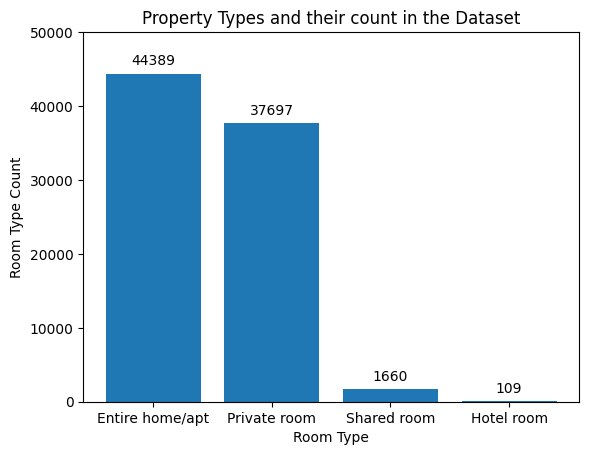

In [64]:
#Room type count plotted on abarchart
room_type_bar=plt.bar(property_types.index,property_types.loc[:,"count"]);
plt.bar_label(room_type_bar,labels=property_types.loc[:,"count"],padding=4);
plt.ylim([0,50000]);
plt.xlabel('Room Type');
plt.ylabel('Room Type Count');
plt.title('Property Types and their count in the Dataset');


In [65]:
hood_group=df['neighbourhood group'].value_counts().to_frame()
hood_group

,count
neighbourhood group,
Brooklyn,34814
Manhattan,34748
Queens,11187
Bronx,2284
Staten Island,822


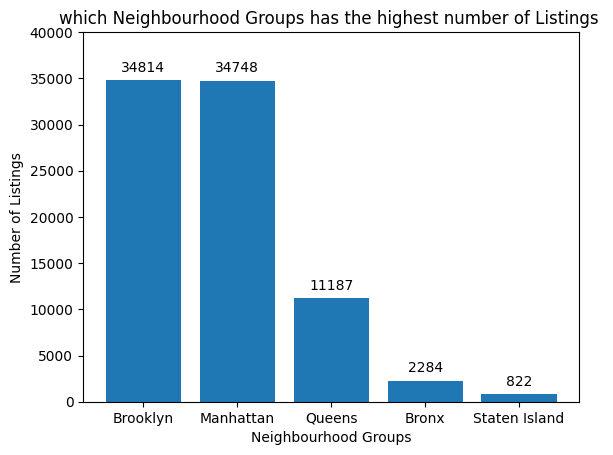

In [66]:
#which neighbourhood groups has the highest number of listings?
hood_group_bar=plt.bar(hood_group.index,hood_group.loc[:,"count"]);
plt.bar_label(hood_group_bar,labels=hood_group.loc[:,"count"],padding=4);
plt.ylim([0,40000]);
plt.xlabel('Neighbourhood Groups');
plt.ylabel('Number of Listings');
plt.title('which Neighbourhood Groups has the highest number of Listings ');

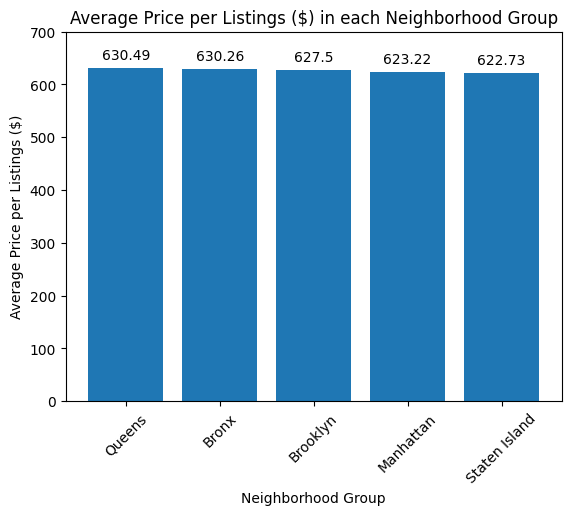

In [67]:
#which neighbourhoods group have the highest average prices for Airbnb listings?
avg_price = df.groupby("neighbourhood group")['price_$'].mean().sort_values(ascending=False).to_frame()
avg_price_bar = plt.bar(avg_price.index, avg_price.loc[:, "price_$"]);
plt.bar_label(avg_price_bar, labels=round(avg_price.loc[:, "price_$"], 2), label_type="edge", padding=4);
plt.ylim([0, 700]);
plt.xlabel('Neighborhood Group');
plt.ylabel('Average Price per Listings ($)');
plt.xticks(rotation=45);
plt.title('Average Price per Listings ($) in each Neighborhood Group');

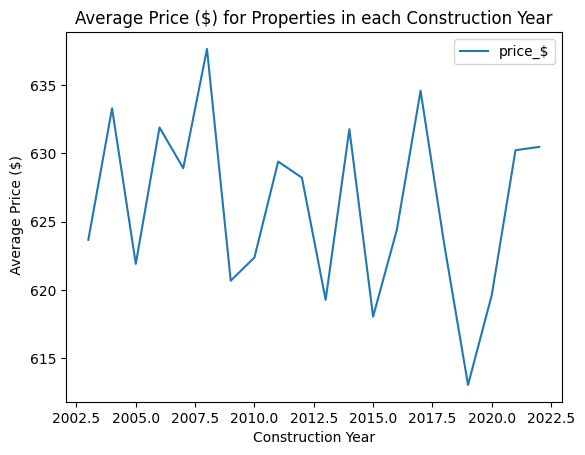

In [68]:
#Is there a relationship between the construction year of property and price?
df.groupby(df['Construction year'])[ 'price_$'].mean().to_frame().plot();
plt.xlabel ('Construction Year');
plt. ylabel(' Average Price ($)');
plt. title( 'Average Price ($) for Properties in each Construction Year');

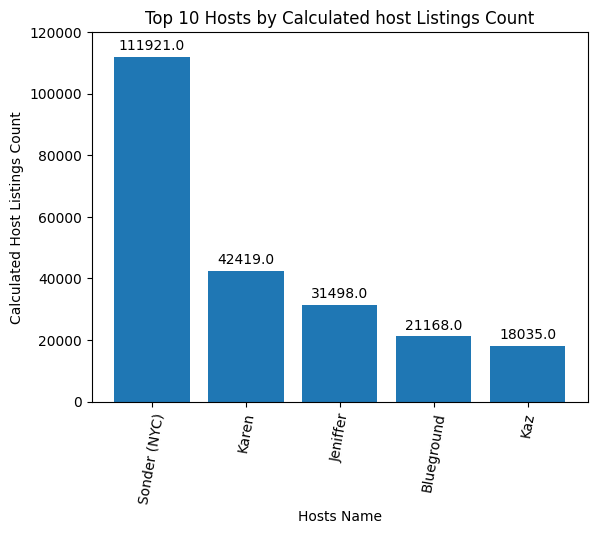

In [69]:
#who are the top 5 hosts by calculated host listing count?
hosts = df.groupby('host name')['calculated host listings count'].sum().sort_values(ascending=False).nlargest(5).to_frame()
hosts_bar = plt.bar(hosts.index, hosts['calculated host listings count']);
plt.bar_label(hosts_bar, labels=hosts['calculated host listings count'], label_type="edge", padding=3);
plt.xlabel('Hosts Name');
plt.ylabel('Calculated Host Listings Count');
plt.xticks(rotation=80);
plt.ylim([0, 120000]);
plt.title('Top 10 Hosts by Calculated host Listings Count');

In [70]:
#Are hosts with verified identities more likely to receive psoitive reviews?
review = df.groupby('host_identity_verified')['review rate number'].mean().sort_values(ascending=False).to_frame()
review

,review rate number
host_identity_verified,
verified,3.285200
unconfirmed,3.273454


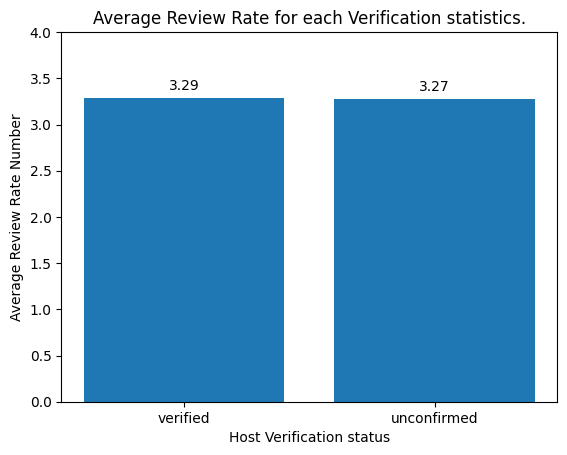

In [71]:
review_bar = plt.bar(review.index, review.loc[:, "review rate number"]);
plt.bar_label(review_bar, labels=round(review.loc[:, "review rate number"], 2), padding=4);
plt.ylim([0,4]);
plt.xlabel ("Host Verification status");
plt.ylabel ('Average Review Rate Number');
plt.title('Average Review Rate for each Verification statistics.');

Text(0.5, 1.0, 'Average Review Rate for each Verification Status')

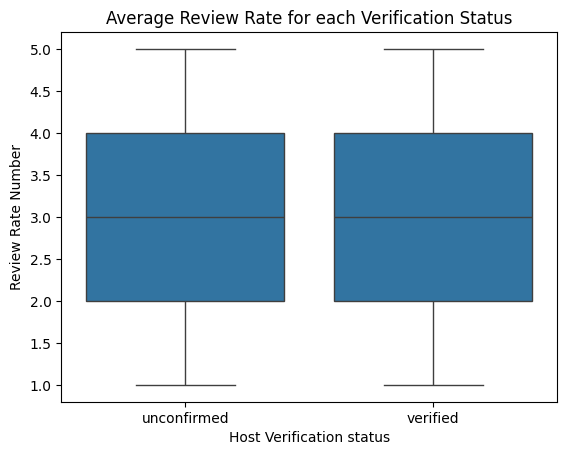

In [72]:
base_color = sns.color_palette()[0]
sns.boxplot(data=df, x="host_identity_verified", y="review rate number", color=base_color)
plt.xlabel('Host Verification status')
plt.ylabel('Review Rate Number')
plt.title('Average Review Rate for each Verification Status')

In [73]:
#Is there a correlation between the price of a lsiting and its service fee?
df['price_$'].corr(df['service_fee_$'])


np.float64(0.9999909085065073)

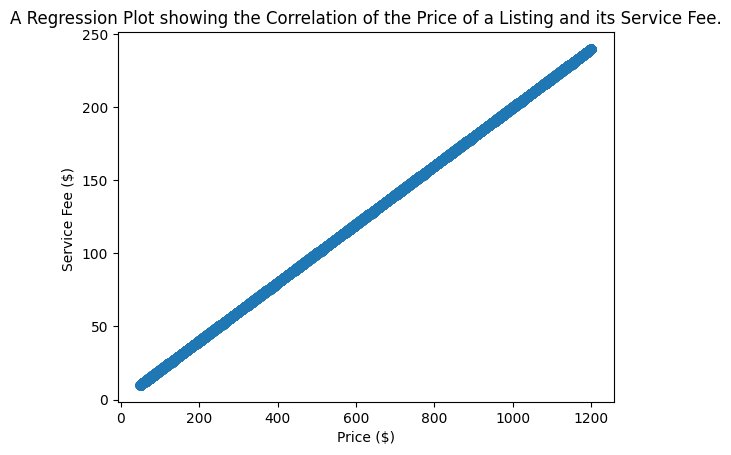

In [74]:
sns.regplot(data=df, x='price_$', y='service_fee_$');
plt.xlabel ('Price ($)');
plt.ylabel ('Service Fee ($) ');
plt. title('A Regression Plot showing the Correlation of the Price of a Listing and its Service Fee.');

In [75]:
#what is the average review rate number(e.g.,stars) for listings , and does it vary based on the neighbour group and room type?
ARRN = df.groupby(['neighbourhood group', 'room type'])['review rate number'].mean().to_frame()
ARRN

review rate number
neighbourhood group room type                          
Bronx               Entire home/apt            3.382151
                    Private room               3.309614
                    Shared room                3.359551
Brooklyn            Entire home/apt            3.243286
                    Hotel room                 3.714286
                    Private room               3.275599
                    Shared room                3.326159
Manhattan           Entire home/apt            3.269107
                    Hotel room                 3.500000
                    Private room               3.285758
                    Shared room                3.265879
Queens              Entire home/apt            3.349732
                    Hotel room                 3.750000
                    Private room               3.311177
                    Shared room                3.332155
Staten Island       Entire home/apt            3.333333
                    Private room               3.500000
                    Shared room                3.714286

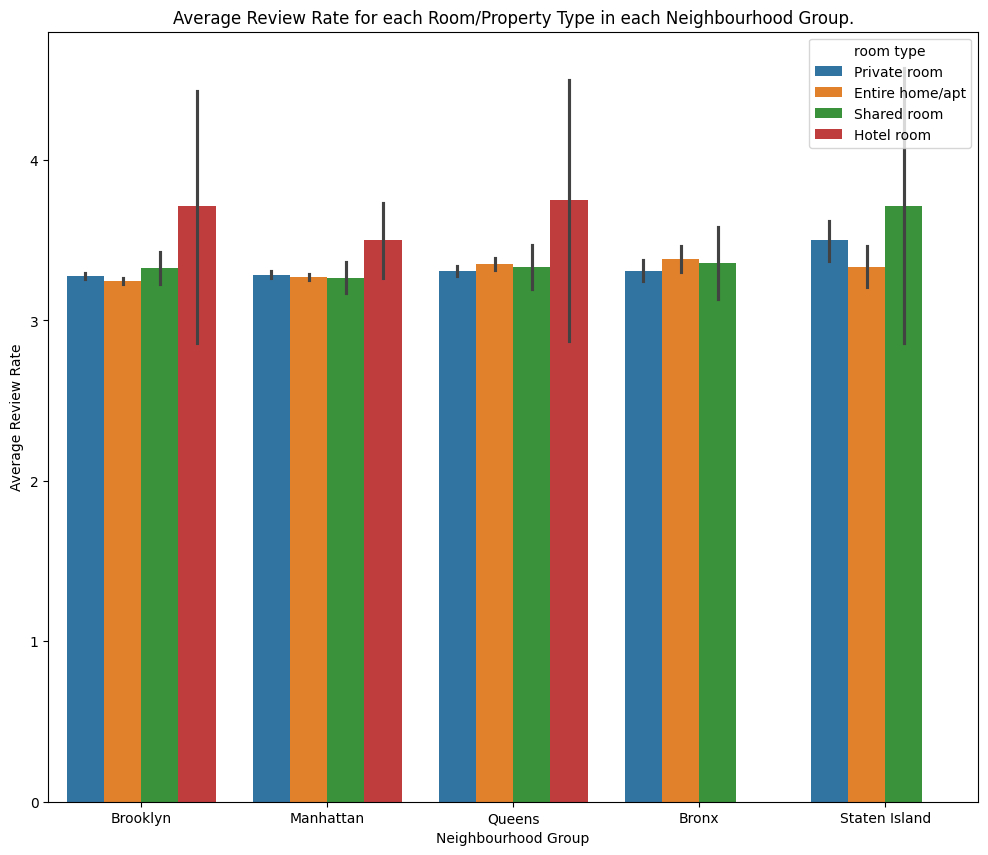

In [76]:
plt.figure(figsize=(12, 10));
sns.barplot(data=df, x='neighbourhood group', y='review rate number', hue="room type");
plt.xlabel('Neighbourhood Group');
plt.ylabel('Average Review Rate');
plt.title('Average Review Rate for each Room/Property Type in each Neighbourhood Group.');

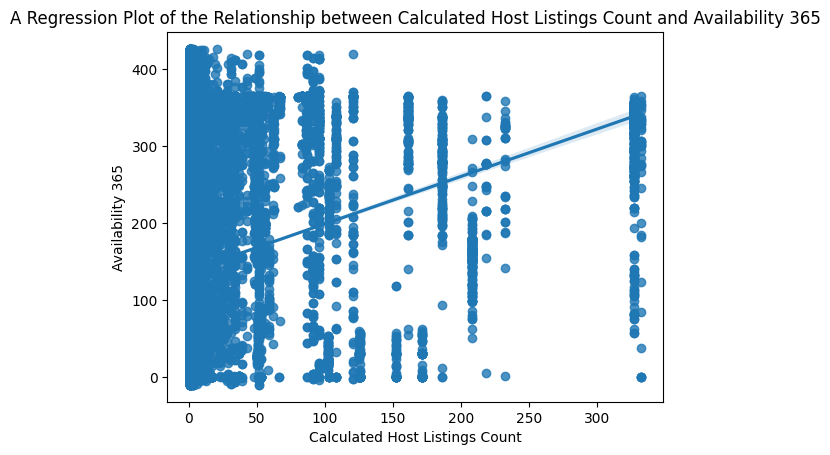

In [77]:
#Are hosts with a higher calculated host listings count more likely to maintain higher availability throughout the year?
sns.regplot(data=df, x="calculated host listings count", y='availability 365');
plt.xlabel('Calculated Host Listings Count');
plt.ylabel('Availability 365');
plt.title("A Regression Plot of the Relationship between Calculated Host Listings Count and Availability 365");

In [79]:
df['calculated host listings count'].corr(df['availability 365'])

np.float64(0.13611047706277576)